In [ ]:
# Make Figures 1 and 2 for benchmarking paper

In [1]:
import numpy as np
from scipy import stats
import statsmodels.api as sm  
#
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#
## this next library contains some helper functions for reshaping FATES variables into easier to work with dimensions
import ctsm_py
import ctsm_py.fates_xarray_funcs as fa       
#
import textwrap
from cmcrameri import cm
import cartopy
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader


ERROR 1: PROJ: proj_create_from_database: Open of /global/homes/j/jkowalcz/.conda/envs/myenv/share/proj failed


In [2]:
shapefile='/global/homes/j/jkowalcz/shapefileamazonecoregionwwf/amazon_ecolola.shp'
Amazon_shapefile=shapefile

In [3]:
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.autolayout'] = False
plt.rcParams['font.size'] = 16
##plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300


In [4]:
path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/SummaryFiles/'

tag='hydro_comp_bmort_kmax_tune_sapflow_kmax3_5xHR_fixSLA_vcmax40.55_fixHR_branch'

file1=tag+'.elm.h0.cat.nc'

d1 = xr.open_dataset(path+file1)

In [5]:
# make mask defining the Amazon eco-region

import shapefile
from shapely.geometry import shape, Point, LinearRing

r = shapefile.Reader(Amazon_shapefile)
shapes = r.shapes()
polygon = shape(shapes[0])

## will need to change range() argument depending on resolution

## shapefile must contain center point of grid cell
Mask = [[1 if polygon.contains(Point(d1.lon[j]-360.,d1.lat[i]))==True else 0 for i in range(23)] for j in range(24)]

Mask = np.array(Mask, dtype='int16')

In [6]:
min_lat_plotting = -22.
max_lat_plotting = 12.
min_lon_plotting = 360.-82.
max_lon_plotting = 360.-42.

geog_range_plotting = [min_lon_plotting, max_lon_plotting, min_lat_plotting, max_lat_plotting]


In [7]:
## Locations of site-scale benchmarking datasets

## Paracou, French Guiana
par_lat=5.2787
par_lon=360.-52.9248

# BIONTE
bionte_lat=-2.638
bionte_lon=360.-60.154725

## Tapajos (TAP) - Brazil - UTC-3
tap_lat=-3.3  
tap_lon=305.0

# Tanguro
## Tanguro - Brazil
tan_lat = -13.08 
tan_lon = 307.59

# K34, Manaus
k34_lat = -2.6091
k34_lon = 360.-60.2093

# GEM sites for NPP allocation: ALP-01, ALP-30, KEN-01, KEN-02, CAX-03, CAX-06, CAX-08, TAM-05, TAM-06
alp_lat=-3.9517
alp_lon=360.-73.43065

ken_lat=-16.01243
ken_lon=360.-62.736385

cax_lat=-1.7879
cax_lon=360.-54.5835

tam_lat=-12.830289
tam_lon=360.-69.270533

In [8]:
site_lons_flx=[par_lon,tap_lon,tan_lon, k34_lon]
site_lats_flx=[par_lat,tap_lat,tan_lat, k34_lat]

site_lons_bionte=[bionte_lon]
site_lats_bionte=[bionte_lat]

site_lons_gem=[alp_lon,ken_lon,cax_lon,tam_lon]
site_lats_gem=[alp_lat,ken_lat,cax_lat,tam_lat]

In [9]:
ba_szpf=fa.scpf_to_scls_by_pft(d1.FATES_BASALAREA_SZPF,d1)

In [18]:
d1.fates_levage

<xarray.DataArray 'fates_levage' (fates_levage: 7)>
array([ 0.,  1.,  2.,  5., 10., 20., 50.], dtype=float32)
Coordinates:
  * fates_levage  (fates_levage) float32 0.0 1.0 2.0 5.0 10.0 20.0 50.0
Attributes:
    long_name:  FATES patch age (yr)

/tmp/ipykernel_43341/2079999712.py:13: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax1 = plt.subplot(2, 2, 1, projection=ccrs.PlateCarree())
/tmp/ipykernel_43341/2079999712.py:14: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax2 = plt.subplot(2, 2, 2, projection=ccrs.PlateCarree())
/tmp/ipykernel_43341/2079999712.py:15: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax3 = plt.subplot(2, 2, 3, projection=ccrs.PlateCarree())


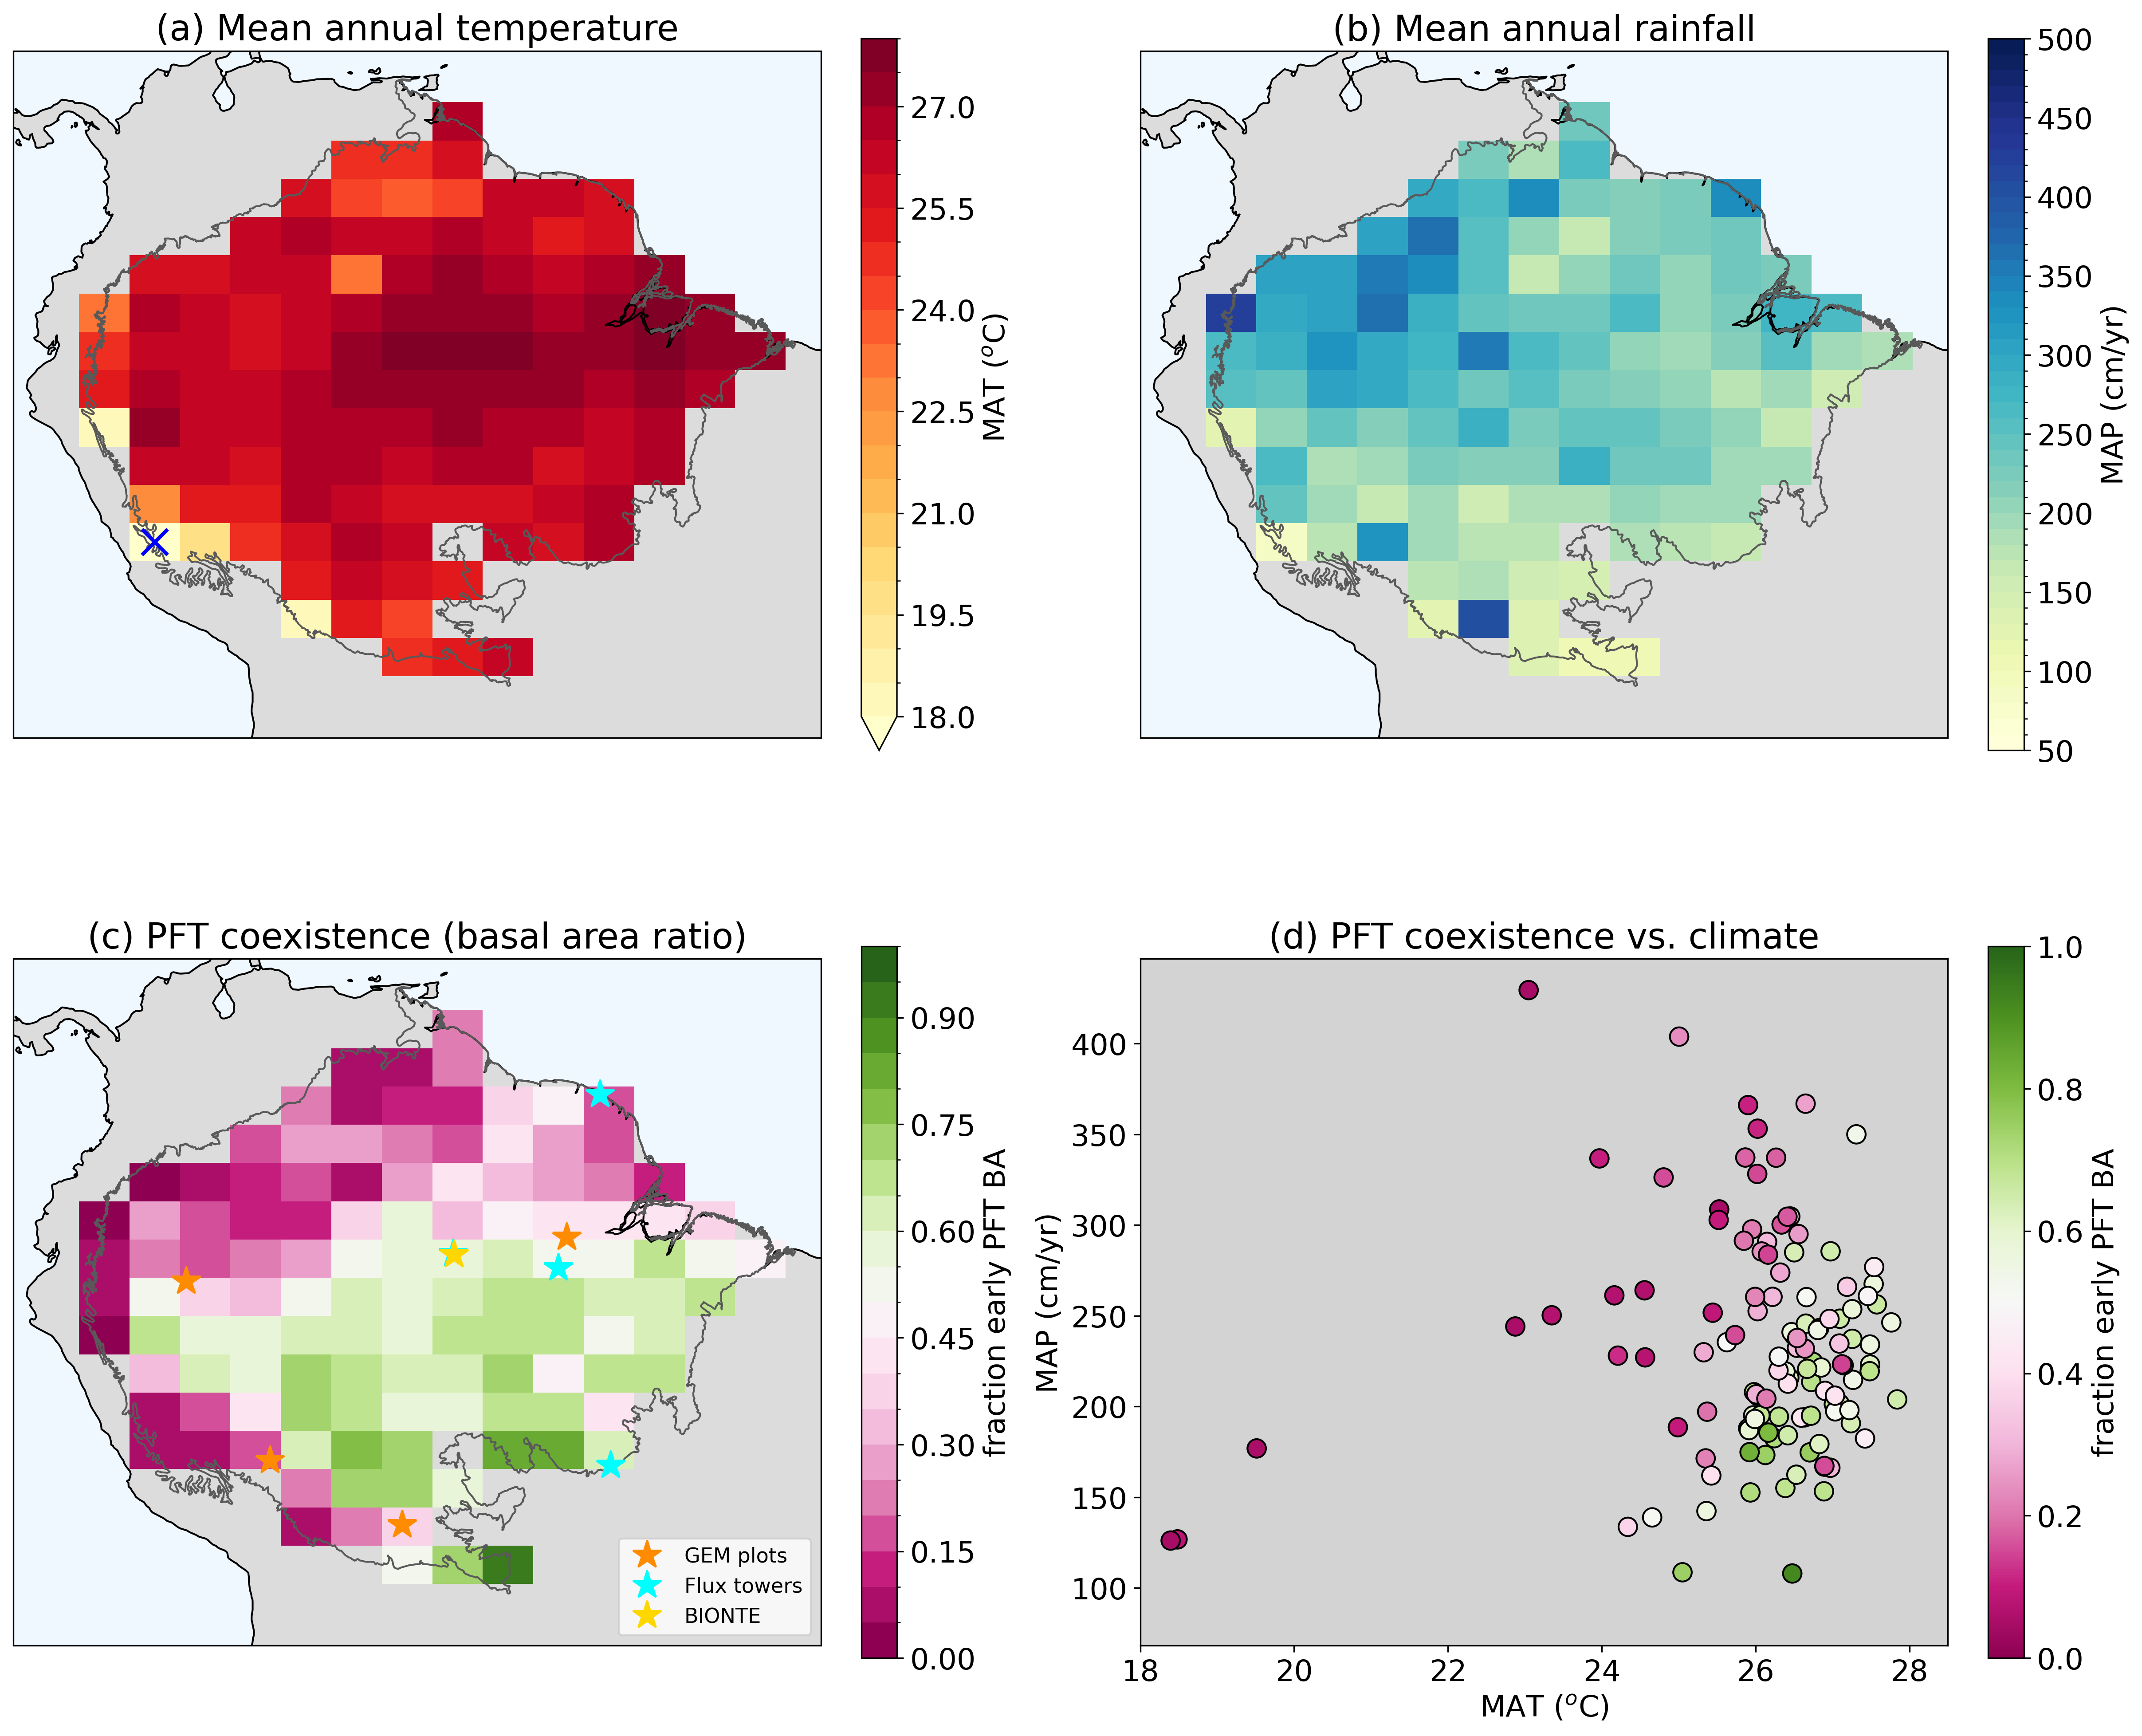

In [10]:
## Figure 1

# converstion factors
mms_to_cmyr=3.154*10**6

# MAP and MAT
rain=mms_to_cmyr*d1.RAIN.mean(dim="time")
temp=d1.TBOT.mean(dim="time")-273.15

# Create figure with 2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)

ax1 = plt.subplot(2, 2, 1, projection=ccrs.PlateCarree())
ax2 = plt.subplot(2, 2, 2, projection=ccrs.PlateCarree())
ax3 = plt.subplot(2, 2, 3, projection=ccrs.PlateCarree())

# First panel - mean annual temp
im1 = temp.where(np.transpose(Mask) > 0).plot(x='lon', y='lat', levels=np.linspace(18,28,21), 
                            cmap=plt.cm.YlOrRd, transform=ccrs.PlateCarree(), ax=ax1, 
                            cbar_kwargs=dict(shrink=0.8,location='right',orientation='vertical',label='MAT ($^o$C)'))
# Mark cold gridcell (MAT < 12) with X
ax1.plot(285, -12.315789, 
        marker='x',           
        markersize=14,
        markerfacecolor='blue',
        markeredgecolor='blue',
        markeredgewidth=2,
        transform=ccrs.PlateCarree())
ax1.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
ax1.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
ax1.set_title('(a) Mean annual temperature')
ax1.coastlines()
ax1.add_geometries(Reader(Amazon_shapefile).geometries(), ccrs.PlateCarree(), 
                   edgecolor=(0.35,0.35,0.35,1), facecolor=(0,0,0,0))
ax1.set_xlim([min_lon_plotting-360., max_lon_plotting-360.])  #desired longitude range
ax1.set_ylim([min_lat_plotting,max_lat_plotting])  # desired latitude range

# Second panel - mean annual precipitation
im2 = rain.where(np.transpose(Mask) > 0).plot(x='lon', y='lat', levels=np.linspace(50,500,46), 
                            cmap=plt.cm.YlGnBu, transform=ccrs.PlateCarree(), ax=ax2,
                            cbar_kwargs=dict(shrink=0.8,location='right',orientation='vertical',label='MAP (cm/yr)'))
ax2.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
ax2.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
ax2.set_title('(b) Mean annual rainfall')
ax2.coastlines()
ax2.add_geometries(Reader(Amazon_shapefile).geometries(), ccrs.PlateCarree(), 
                           edgecolor=(0.35,0.35,0.35,1), facecolor=(0,0,0,0))
ax2.set_xlim([min_lon_plotting-360., max_lon_plotting-360.])  #desired longitude range
ax2.set_ylim([min_lat_plotting,max_lat_plotting])  # desired latitude range

# Third panel -- coexistence (basal area ratio) with sites marked
pft_ratio=(ba_szpf.sum(dim='fates_levscls').isel(fates_levpft=0).mean(dim="time"))/(ba_szpf.sum(dim='fates_levscls').sum(dim='fates_levpft').mean(dim="time"))

im3=pft_ratio.where(np.transpose(Mask) > 0).plot(x='lon', y='lat',levels=np.linspace(0,1,21),cmap=plt.cm.PiYG,transform=ccrs.PlateCarree(),ax=ax3,cbar_kwargs=dict(shrink=0.8,location='right',orientation='vertical',label='fraction early PFT BA'))
ax3.plot(site_lons_gem, site_lats_gem, 
        marker='*',           
        markersize=16,
        markerfacecolor='darkorange',
        markeredgecolor='darkorange',
        markeredgewidth=1,
        linestyle='none',     # no line connecting points
        transform=ccrs.PlateCarree(),
        label='GEM plots')
ax3.plot(site_lons_flx, site_lats_flx, 
        marker='*',           
        markersize=16,
        markerfacecolor='cyan',
        markeredgecolor='cyan',
        markeredgewidth=1,
        linestyle='none',     
        transform=ccrs.PlateCarree(),
        label='Flux towers')
ax3.plot(site_lons_bionte, site_lats_bionte, 
        marker='*',           
        markersize=16,
        markerfacecolor='gold',
        markeredgecolor='gold',
        markeredgewidth=1,
        linestyle='none',     
        transform=ccrs.PlateCarree(),
        label='BIONTE')
ax3.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
ax3.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
ax3.legend(fontsize='x-small',loc='lower right')
ax3.set_title('(c) PFT coexistence (basal area ratio)')
ax3.coastlines()
ax3.add_geometries(Reader(Amazon_shapefile).geometries(),ccrs.PlateCarree(),edgecolor=(0.35,0.35,0.35,1),facecolor=(0,0,0,0))
ax3.set_xlim([min_lon_plotting-360., max_lon_plotting-360.])  #desired longitude range
ax3.set_ylim([min_lat_plotting,max_lat_plotting])  # desired latitude range

# Fourth panel -- PFT coexistence vs climate

x_temp = temp.where(np.transpose(Mask) > 0).values.flatten()
x_rain = rain.where(np.transpose(Mask) > 0).values.flatten()
y = pft_ratio.where(np.transpose(Mask) > 0).values.flatten()

scatter = ax4.scatter(
    x_temp,
    x_rain,
    c=y,
    s=100,
    alpha=1,
    edgecolor="black",
    linewidth=1,
    cmap=plt.cm.PiYG,
    vmin=0,
    vmax=1,
)

ax4.set_xlabel("MAT ($^o$C)")
ax4.set_ylabel("MAP (cm/yr)")
ax4.set_title("(d) PFT coexistence vs. climate")
ax4.set_xlim(18,28.5)
ax4.set_facecolor("lightgrey")
cbar = fig.colorbar(scatter, ax=ax4, shrink=0.8, label="fraction early PFT BA")

# Size figure
target_width = 16.0  # Total figure width in inches

# Calculate span of data
lon_span = max_lon_plotting - min_lon_plotting
lat_span = max_lat_plotting - min_lat_plotting

# Aspect ratio of a single panel (Height / Width)
# Note: Near the equator, 1 degree lat ≈ 1 degree lon. 
panel_aspect = lat_span / lon_span 

# Because it's a 2x2 grid, the total figure height/width ratio 
# matches a single panel's height/width ratio.
target_height = target_width * panel_aspect

# 1. Update the overall canvas size
fig.set_size_inches(target_width, target_height)

# 2. Force ax4 to match the physical box aspect ratio of ax3 now that the canvas is right
ax4.set_box_aspect(panel_aspect)

plt.show()

In [11]:
# Multivariate regression of PFT coexistence (PFT BA ratio) vs temperature and rainfall with interaction term.

# Clean data -- there is one cold grid cell with MAT < 18 C (11.something)
mask = ~np.isnan(x_temp) & ~np.isnan(x_rain) & ~np.isnan(y) & (x_temp > 18.)
temp_clean = x_temp[mask]
rain_clean = x_rain[mask]
y_clean = y[mask]
    
# Model WITHOUT interaction
X_no_int = sm.add_constant(np.column_stack([temp_clean, rain_clean]))
model_no_int = sm.OLS(y_clean, X_no_int).fit()
    
# Model WITH interaction
X_with_int = sm.add_constant(np.column_stack([
        temp_clean,
        rain_clean,
        temp_clean * rain_clean
    ]))
model_with_int = sm.OLS(y_clean, X_with_int).fit()
    
# Print model comparison
print("\nModel WITHOUT interaction:")
print(f"  R²: {model_no_int.rsquared:.4f}, Adjusted R²: {model_no_int.rsquared_adj:.4f}")
print(f"  AIC: {model_no_int.aic:.2f}, BIC: {model_no_int.bic:.2f}")
print(f"  Temperature coeff: {model_no_int.params[1]:.6f} (p={model_no_int.pvalues[1]:.4e})")
print(f"  Rainfall coeff: {model_no_int.params[2]:.6f} (p={model_no_int.pvalues[2]:.4e})")
    
print("\nModel WITH interaction:")
print(f"  R²: {model_with_int.rsquared:.4f}, Adjusted R²: {model_with_int.rsquared_adj:.4f}")
print(f"  AIC: {model_with_int.aic:.2f}, BIC: {model_with_int.bic:.2f}")
print(f"  Temperature coeff: {model_with_int.params[1]:.6f} (p={model_with_int.pvalues[1]:.4e})")
print(f"  Rainfall coeff: {model_with_int.params[2]:.6f} (p={model_with_int.pvalues[2]:.4e})")
print(f"  Interaction coeff: {model_with_int.params[3]:.6f} (p={model_with_int.pvalues[3]:.4e})")
    
# F-test for interaction significance - FIXED
f_test_result = model_with_int.compare_f_test(model_no_int)
f_pval = f_test_result[1]  # p-value is the second element
print(f"\nF-test for interaction term: p={f_pval:.4e}")
    
if f_pval < 0.05:
    print("→ Interaction term is significant, use model WITH interaction")
else:
    print("→ Interaction term is not significant, simpler model may be preferred")



Model WITHOUT interaction:
  R²: 0.5374, Adjusted R²: 0.5295
  AIC: -97.91, BIC: -89.53
  Temperature coeff: 0.087561 (p=4.7941e-15)
  Rainfall coeff: -0.002030 (p=1.7748e-13)

Model WITH interaction:
  R²: 0.5376, Adjusted R²: 0.5257
  AIC: -95.98, BIC: -84.79
  Temperature coeff: 0.080845 (p=5.6800e-03)
  Rainfall coeff: -0.002932 (p=4.2091e-01)
  Interaction coeff: 0.000036 (p=8.0383e-01)

F-test for interaction term: p=8.0383e-01
→ Interaction term is not significant, simpler model may be preferred


In [12]:
# Repeat statistical analysis with a stricter temperature criteria, excluding the 
# four grid cells with MAT < 22 C

mask = ~np.isnan(x_temp) & ~np.isnan(x_rain) & ~np.isnan(y) & (x_temp > 22.)
temp_clean = x_temp[mask]
rain_clean = x_rain[mask]
y_clean = y[mask]
    
# Model WITHOUT interaction
X_no_int = sm.add_constant(np.column_stack([temp_clean, rain_clean]))
model_no_int = sm.OLS(y_clean, X_no_int).fit()
    
# Model WITH interaction
X_with_int = sm.add_constant(np.column_stack([
        temp_clean,
        rain_clean,
        temp_clean * rain_clean
    ]))
model_with_int = sm.OLS(y_clean, X_with_int).fit()
    
# Print model comparison
print("\nModel WITHOUT interaction:")
print(f"  R²: {model_no_int.rsquared:.4f}, Adjusted R²: {model_no_int.rsquared_adj:.4f}")
print(f"  AIC: {model_no_int.aic:.2f}, BIC: {model_no_int.bic:.2f}")
print(f"  Temperature coeff: {model_no_int.params[1]:.6f} (p={model_no_int.pvalues[1]:.4e})")
print(f"  Rainfall coeff: {model_no_int.params[2]:.6f} (p={model_no_int.pvalues[2]:.4e})")
    
print("\nModel WITH interaction:")
print(f"  R²: {model_with_int.rsquared:.4f}, Adjusted R²: {model_with_int.rsquared_adj:.4f}")
print(f"  AIC: {model_with_int.aic:.2f}, BIC: {model_with_int.bic:.2f}")
print(f"  Temperature coeff: {model_with_int.params[1]:.6f} (p={model_with_int.pvalues[1]:.4e})")
print(f"  Rainfall coeff: {model_with_int.params[2]:.6f} (p={model_with_int.pvalues[2]:.4e})")
print(f"  Interaction coeff: {model_with_int.params[3]:.6f} (p={model_with_int.pvalues[3]:.4e})")
    
# F-test for interaction significance - FIXED
f_test_result = model_with_int.compare_f_test(model_no_int)
f_pval = f_test_result[1]  # p-value is the second element
print(f"\nF-test for interaction term: p={f_pval:.4e}")
    
if f_pval < 0.05:
    print("→ Interaction term is significant, use model WITH interaction")
else:
    print("→ Interaction term is not significant, simpler model may be preferred")



Model WITHOUT interaction:
  R²: 0.5170, Adjusted R²: 0.5086
  AIC: -95.09, BIC: -86.78
  Temperature coeff: 0.107385 (p=3.1677e-10)
  Rainfall coeff: -0.001921 (p=1.0028e-11)

Model WITH interaction:
  R²: 0.5259, Adjusted R²: 0.5134
  AIC: -95.27, BIC: -84.19
  Temperature coeff: 0.188528 (p=1.4414e-03)
  Rainfall coeff: 0.006386 (p=2.6475e-01)
  Interaction coeff: -0.000323 (p=1.4722e-01)

F-test for interaction term: p=1.4722e-01
→ Interaction term is not significant, simpler model may be preferred


In [14]:
canopy_growth=fa.scpf_to_scls_by_pft(d1.FATES_DDBH_CANOPY_SZPF,d1)
nplant_canopy=fa.scpf_to_scls_by_pft(d1.FATES_NPLANT_CANOPY_SZPF,d1)

In [74]:
d1.fates_levscls

<xarray.DataArray 'fates_levscls' (fates_levscls: 13)>
array([  0.,   5.,  10.,  15.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90.,
       100.], dtype=float32)
Coordinates:
  * fates_levscls  (fates_levscls) float32 0.0 5.0 10.0 15.0 ... 80.0 90.0 100.0
Attributes:
    long_name:  FATES diameter size class lower bound
    units:      cm

In [15]:
# Repeat statistical analysis with a stricter temperature criteria, excluding the 
# four grid cells with MAT < 22 C

canopy_growth_rate=100.*canopy_growth.isel(fates_levscls=slice(0,4)).mean(dim='time')/nplant_canopy.isel(fates_levscls=slice(0,4)).mean(dim='time')
    
# Response variables
y1=canopy_growth_rate.isel(fates_levpft=0).mean(dim='fates_levscls').where(np.transpose(Mask) > 0).values.flatten()
y2=canopy_growth_rate.isel(fates_levpft=1).mean(dim='fates_levscls').where(np.transpose(Mask) > 0).values.flatten()
    
# Clean data and fit models
models = []
data_sets = []
labels = ['Early PFT', 'Late PFT']
colors = ['lightgreen', 'orange']
line_colors = ['green', 'red']
    
for y_data in [y1, y2]:
    mask = ~np.isnan(x_temp) & ~np.isnan(x_rain) & ~np.isnan(y_data) & (x_temp > 22)
    temp_clean = x_temp[mask]
    rain_clean = x_rain[mask]
    y_clean = y_data[mask]
        
# Create design matrix with interaction
    X = np.column_stack([
        np.ones(temp_clean.shape),           # Constant
        temp_clean,                          # Temperature
        rain_clean,                          # Rainfall
        temp_clean * rain_clean              # Interaction
    ])
        
# Fit model
    model = sm.OLS(y_clean, X).fit()
    models.append(model)
    data_sets.append({'temp': temp_clean, 'rain': rain_clean, 'growth': y_clean})
    
    # Print model summaries
print("=" * 80)

for i, (model, label) in enumerate(zip(models, labels)):
    print(f"\n{label}:")
    print(f"  R²: {model.rsquared:.4f}, Adjusted R²: {model.rsquared_adj:.4f}")
    print(f"  Temperature coeff: {model.params[1]:.6f} (p={model.pvalues[1]:.4e})")
    print(f"  Rainfall coeff: {model.params[2]:.6f} (p={model.pvalues[2]:.4e})")
    print(f"  Interaction coeff: {model.params[3]:.6f} (p={model.pvalues[3]:.4e})")


Early PFT:
  R²: 0.6075, Adjusted R²: 0.5971
  Temperature coeff: -0.113275 (p=5.4330e-04)
  Rainfall coeff: -0.003145 (p=3.1883e-01)
  Interaction coeff: 0.000171 (p=1.6390e-01)

Late PFT:
  R²: 0.6283, Adjusted R²: 0.6185
  Temperature coeff: -0.035584 (p=2.4095e-03)
  Rainfall coeff: -0.000212 (p=8.5202e-01)
  Interaction coeff: 0.000025 (p=5.7224e-01)


In [16]:
# Look at canopy growth rates (DBH < 20 cm) vs climate

canopy_growth_rate=100.*canopy_growth.isel(fates_levscls=slice(0,4)).mean(dim='time')/nplant_canopy.isel(fates_levscls=slice(0,4)).mean(dim='time')
    
# Response variables
y1=canopy_growth_rate.isel(fates_levpft=0).mean(dim='fates_levscls').where(np.transpose(Mask) > 0).values.flatten()
y2=canopy_growth_rate.isel(fates_levpft=1).mean(dim='fates_levscls').where(np.transpose(Mask) > 0).values.flatten()
    
# Clean data and fit models
models = []
data_sets = []
labels = ['Early PFT', 'Late PFT']
colors = ['lightgreen', 'orange']
line_colors = ['green', 'red']
    
for y_data in [y1, y2]:
    mask = ~np.isnan(x_temp) & ~np.isnan(x_rain) & ~np.isnan(y_data) & (x_temp > 18)
    temp_clean = x_temp[mask]
    rain_clean = x_rain[mask]
    y_clean = y_data[mask]
        
# Create design matrix with interaction
    X = np.column_stack([
        np.ones(temp_clean.shape),           # Constant
        temp_clean,                          # Temperature
        rain_clean,                          # Rainfall
        temp_clean * rain_clean              # Interaction
    ])
        
# Fit model
    model = sm.OLS(y_clean, X).fit()
    models.append(model)
    data_sets.append({'temp': temp_clean, 'rain': rain_clean, 'growth': y_clean})
    
    # Print model summaries
print("=" * 80)

for i, (model, label) in enumerate(zip(models, labels)):
    print(f"\n{label}:")
    print(f"  R²: {model.rsquared:.4f}, Adjusted R²: {model.rsquared_adj:.4f}")
    print(f"  Temperature coeff: {model.params[1]:.6f} (p={model.pvalues[1]:.4e})")
    print(f"  Rainfall coeff: {model.params[2]:.6f} (p={model.pvalues[2]:.4e})")
    print(f"  Interaction coeff: {model.params[3]:.6f} (p={model.pvalues[3]:.4e})")


Early PFT:
  R²: 0.6956, Adjusted R²: 0.6878
  Temperature coeff: -0.095405 (p=1.2641e-08)
  Rainfall coeff: -0.001419 (p=4.7293e-01)
  Interaction coeff: 0.000104 (p=1.8118e-01)

Late PFT:
  R²: 0.7504, Adjusted R²: 0.7440
  Temperature coeff: -0.041081 (p=3.4065e-11)
  Rainfall coeff: -0.000644 (p=3.6596e-01)
  Interaction coeff: 0.000041 (p=1.4013e-01)


/tmp/ipykernel_802411/3519018285.py:6: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax3 = plt.subplot(2, 2, 3, projection=ccrs.PlateCarree())
/tmp/ipykernel_802411/3519018285.py:7: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax4 = plt.subplot(2, 2, 4, projection=ccrs.PlateCarree())


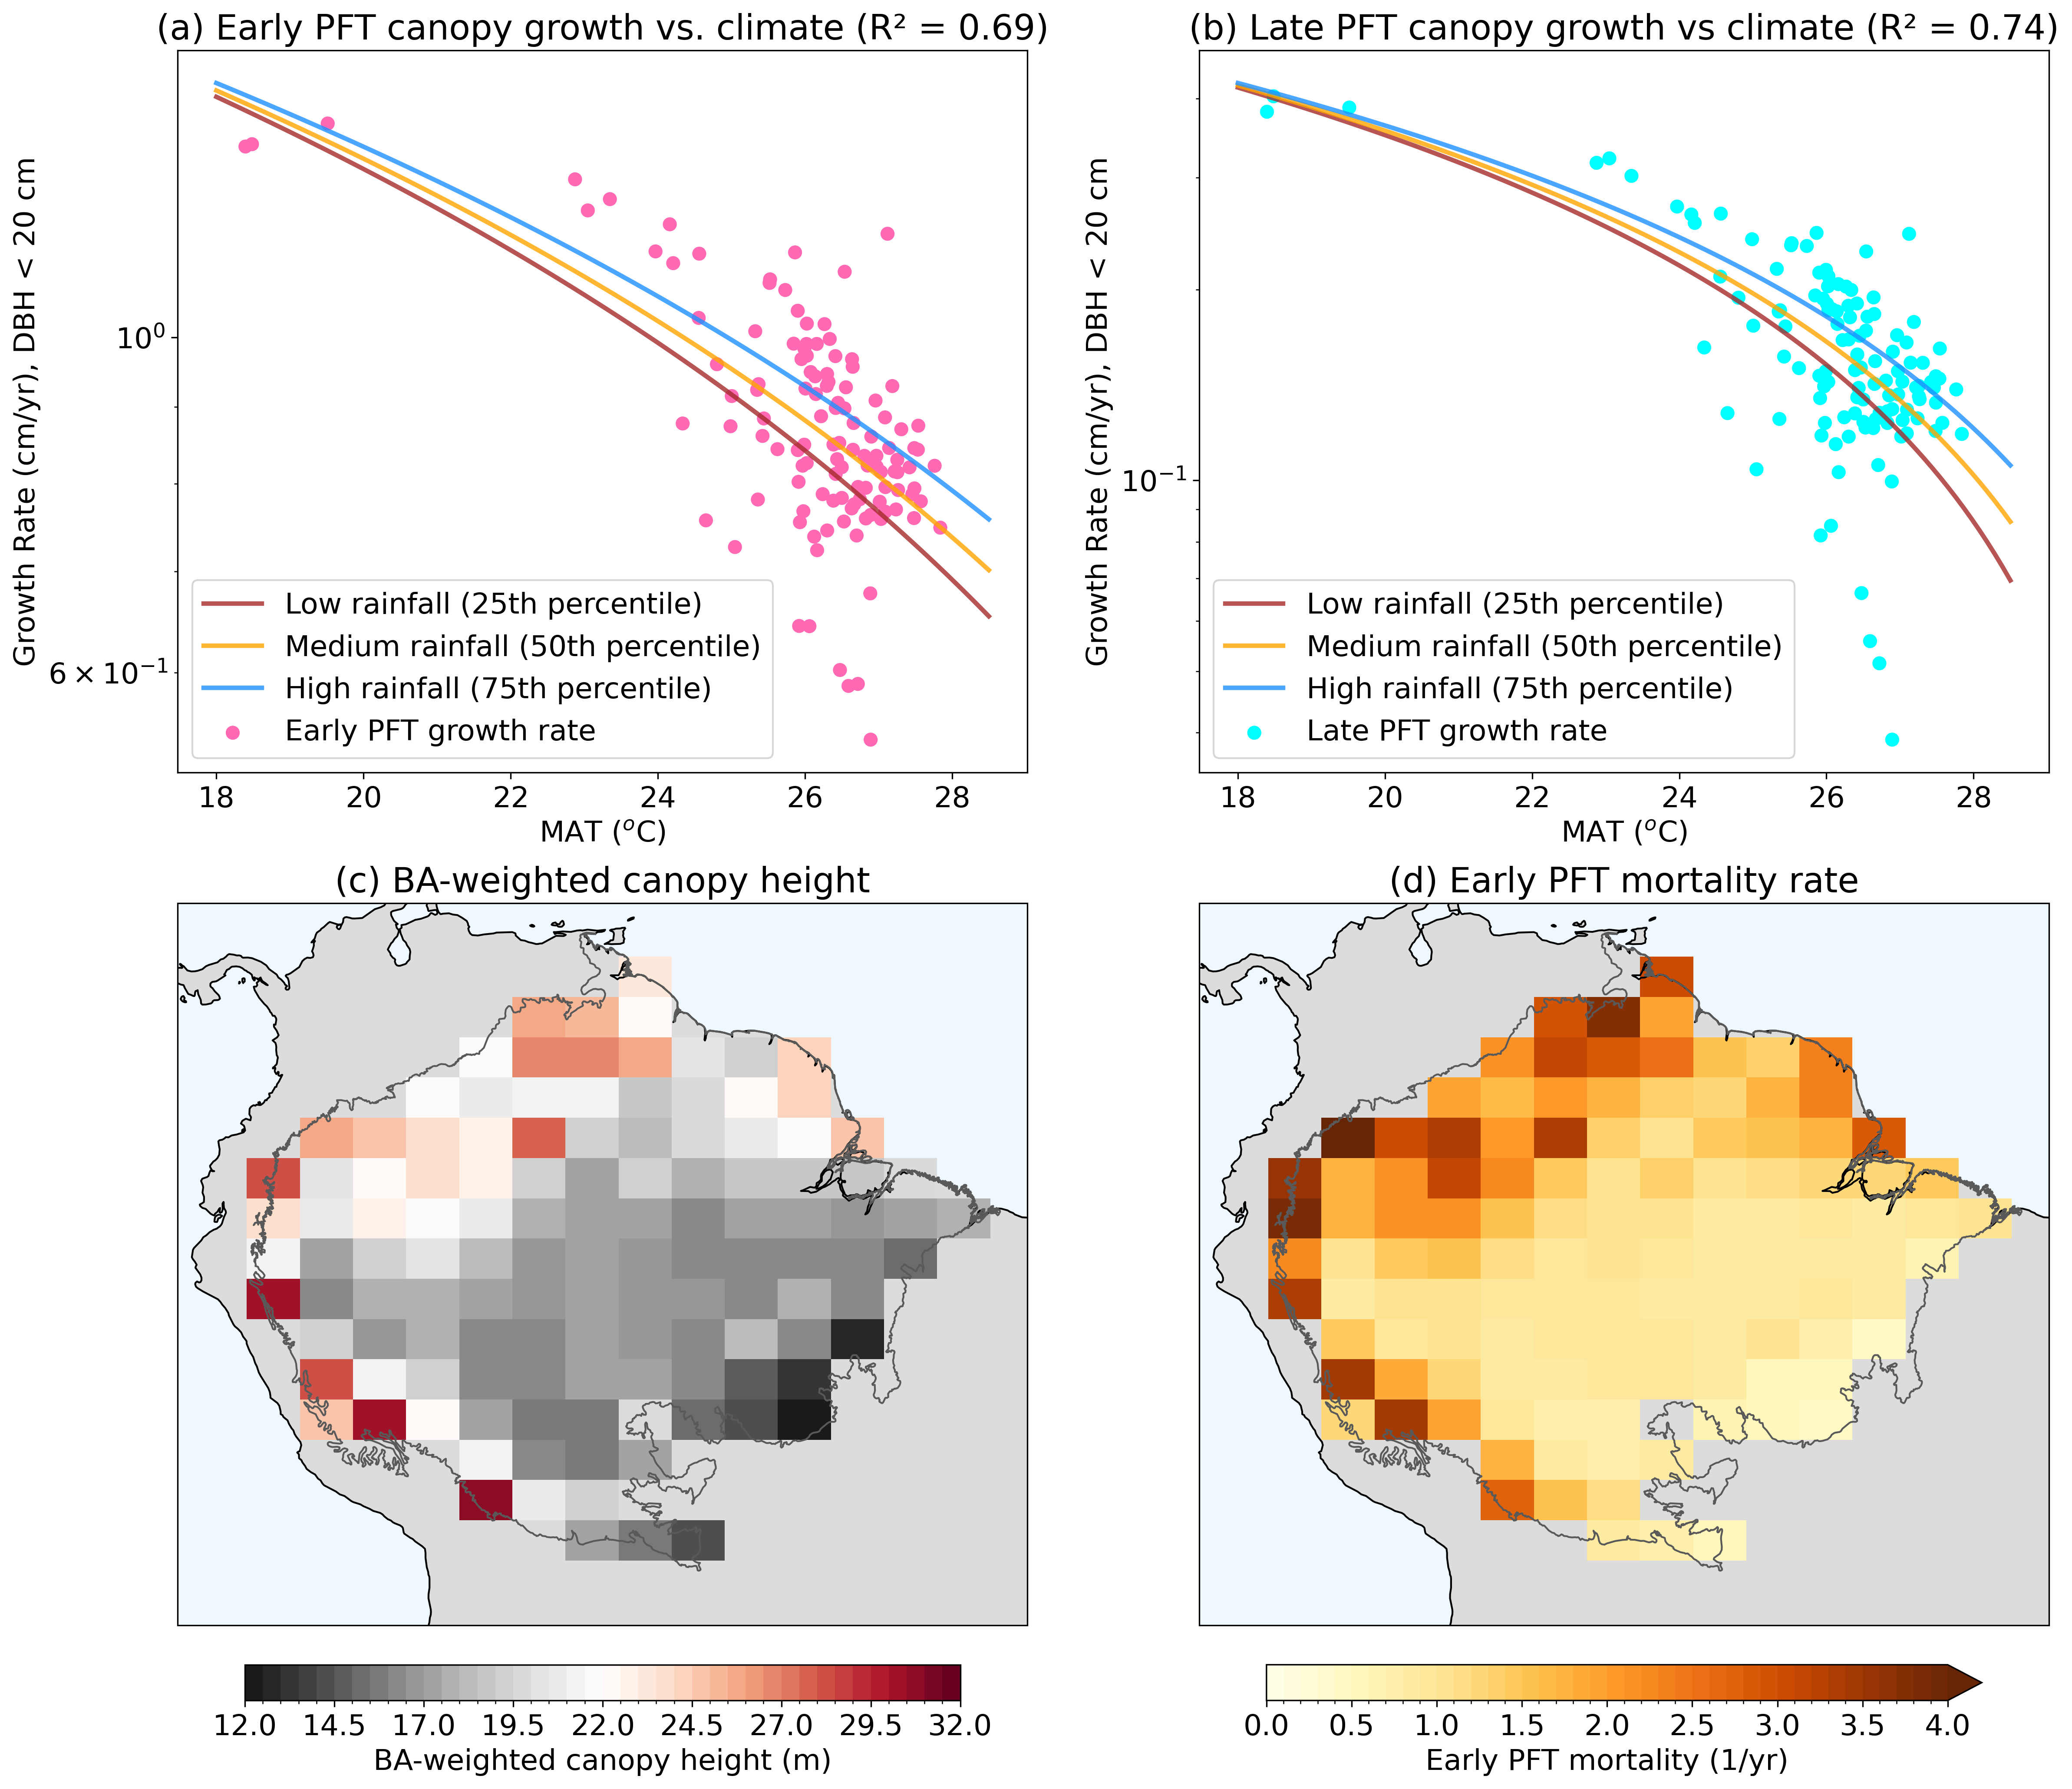

In [25]:
# Figure 2: canopy growth rates vs climate, canopy height, and early PFT mortality

# Create figure with 2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2)

ax3 = plt.subplot(2, 2, 3, projection=ccrs.PlateCarree())
ax4 = plt.subplot(2, 2, 4, projection=ccrs.PlateCarree())

## Panels 1 & 2: growth rates vs climate

# Select 3 rainfall levels (low, medium, high)
all_rain = np.concatenate([d['rain'] for d in data_sets])
rain_levels = np.percentile(all_rain, [25, 50, 75])
rain_colors = ['brown', 'orange', 'dodgerblue']
rain_labels = ['Low rainfall (25th percentile)', 'Medium rainfall (50th percentile)', 'High rainfall (75th percentile)']

temp_range = np.linspace(18, 28.5, 100)

## Panel 1: Early PFT canopy growth rate vs climate
for rain_val, rain_color, rain_label in zip(rain_levels, rain_colors, rain_labels):
        # Predict growth at this rainfall level across temperature range
    X_slice = np.column_stack([
        np.ones(temp_range.shape),
        temp_range,
        np.full(temp_range.shape, rain_val),
        temp_range * rain_val
    ])
    growth_slice = models[0].predict(X_slice)
        
    ax1.plot(temp_range, growth_slice, color=rain_color, linewidth=2.5, label=f'{rain_label}', alpha=0.8)
        
        # Overlay actual data points
ax1.scatter(data_sets[0]['temp'], data_sets[0]['growth'], c="hotpink", alpha=1, s=60, 
                  edgecolor='none', label='Early PFT growth rate')
ax1.set_xlabel('MAT ($^o$C)')
ax1.set_ylabel('Growth Rate (cm/yr), DBH < 20 cm')
ax1.set_title(f'(a) Early PFT canopy growth vs. climate (R² = {models[0].rsquared_adj:.2f})')
ax1.legend(loc='best')
ax1.set_yscale('log')

## Panel 2: Late PFT canopy growth rate vs climate
for rain_val, rain_color, rain_label in zip(rain_levels, rain_colors, rain_labels):
    X_slice = np.column_stack([
        np.ones(temp_range.shape),
        temp_range,
        np.full(temp_range.shape, rain_val),
        temp_range * rain_val
    ])
    growth_slice = models[1].predict(X_slice)
        
    ax2.plot(temp_range, growth_slice, color=rain_color, linewidth=2.5, label=f'{rain_label}', alpha=0.8)
        
ax2.scatter(data_sets[1]['temp'], data_sets[1]['growth'], c="cyan", alpha=1, s=60, 
                  edgecolor='none', label='Late PFT growth rate')
ax2.set_xlabel('MAT ($^o$C)')
ax2.set_ylabel('Growth Rate (cm/yr), DBH < 20 cm')
ax2.set_title(f'(b) Late PFT canopy growth vs climate (R² = {models[1].rsquared_adj:.2f})')
ax2.legend(loc='best')
ax2.set_yscale('log')
  
## Panel 3: BA-weighted canopy height

im3=d1.FATES_BA_WEIGHTED_HEIGHT.mean(dim='time').where(np.transpose(Mask) > 0).plot(x='lon', y='lat',levels=np.linspace(12,32,41),ax=ax3,cmap=plt.cm.RdGy_r,transform=ccrs.PlateCarree(),cbar_kwargs=dict(shrink=0.8,location='bottom',orientation='horizontal',label='BA-weighted canopy height (m)'))
ax3.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
ax3.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
ax3.set_title('(c) BA-weighted canopy height')
ax3.coastlines()
ax3.add_geometries(Reader(Amazon_shapefile).geometries(), ccrs.PlateCarree(), 
                           edgecolor=(0.35,0.35,0.35,1), facecolor=(0,0,0,0))
ax3.set_xlim([min_lon_plotting-360., max_lon_plotting-360.])  #desired longitude range
ax3.set_ylim([min_lat_plotting,max_lat_plotting])  # desired latitude range

#3 Panel 4: early PFT mortality rate
mort = d1.FATES_MORTALITY_PF.mean(dim='time')/d1.FATES_NPLANT_PF.mean(dim='time')

im4 = mort.isel(fates_levpft=0).where(np.transpose(Mask) > 0).plot(x='lon', y='lat', levels=np.linspace(0,4,41), 
                            cmap=plt.cm.YlOrBr, transform=ccrs.PlateCarree(), ax=ax4, cbar_kwargs=dict(shrink=0.8,location='bottom',orientation='horizontal',label='Early PFT mortality (1/yr)'))
ax4.add_feature(cartopy.feature.LAND, facecolor='gainsboro', zorder=0)
ax4.add_feature(cartopy.feature.OCEAN, facecolor='aliceblue', zorder=0)
ax4.set_title('(d) Early PFT mortality rate')
ax4.coastlines()
ax4.add_geometries(Reader(Amazon_shapefile).geometries(), ccrs.PlateCarree(), 
                   edgecolor=(0.35,0.35,0.35,1), facecolor=(0,0,0,0))
ax4.set_xlim([min_lon_plotting-360., max_lon_plotting-360.])  #desired longitude range
ax4.set_ylim([min_lat_plotting,max_lat_plotting])  # desired latitude range

# Size figure
target_width = 16.0  # Total figure width in inches

lon_span = max_lon_plotting - min_lon_plotting
lat_span = max_lat_plotting - min_lat_plotting

panel_aspect = lat_span / lon_span 

target_height = target_width * panel_aspect

fig.set_size_inches(target_width, target_height)

ax1.set_box_aspect(panel_aspect)
ax2.set_box_aspect(panel_aspect)

plt.show()
 